##### import libraries

In [1]:
import pickle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.svm import OneClassSVM
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.manifold import TSNE
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_predict, cross_val_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm import tqdm
from sklearn.utils import shuffle
import math
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from torch.autograd import grad

In [ ]:
np.random.seed(42)
torch.manual_seed(42)

##### load features

In [2]:
def load_pickle_data(file_path):
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    return data


coh_base_dir = "../data/COH/"
pli_base_dir = "../data/PLI/"
ste_base_dir = "../data/STE/"


BD_coh  = load_pickle_data(coh_base_dir + "BD_coh_data.pkl")
BD_pli  = load_pickle_data(pli_base_dir + "BD_pli_data.pkl")
MDD_coh = load_pickle_data(coh_base_dir + "MDD_coh_data.pkl")
MDD_pli = load_pickle_data(pli_base_dir + "MDD_pli_data.pkl")
BD_ste  = load_pickle_data(ste_base_dir + "BD_ste_data.pkl")
MDD_ste = load_pickle_data(ste_base_dir + "MDD_ste_data.pkl")

##### feature selection

In [3]:
def combine_features_all(subject_id, coh_dict, pli_dict, ste_dict):
    
    frequency_bands = ["delta", "theta", "alpha", "betalow", "betahigh", "gamma"]
    features = []
    # COH
    for band in frequency_bands:
        features.append(coh_dict[subject_id][band])
    # PLI
    for band in frequency_bands:
        features.append(pli_dict[subject_id][band])
    # STE
    for band in frequency_bands:
        matrix = ste_dict[subject_id][band] 
        mask = np.ones(matrix.shape, dtype=bool)
        np.fill_diagonal(mask, False)
        vector = matrix[mask] 
        features.append(vector)
    return np.concatenate(features)

In [4]:
BD_subjects = sorted(BD_coh.keys())
MDD_subjects = sorted(MDD_coh.keys())


n_train_BD = 45
n_train_MDD = 45

BD_train_ids = BD_subjects[:n_train_BD]
BD_test_ids  = BD_subjects[n_train_BD:]
MDD_train_ids = MDD_subjects[:n_train_MDD]
MDD_test_ids  = MDD_subjects[n_train_MDD:]

In [5]:
X_train_list = []
y_train_list = []
train_ids = []

for subj in BD_train_ids:
    feat_vector = combine_features_all(subj, BD_coh, BD_pli, BD_ste)
    X_train_list.append(feat_vector)
    y_train_list.append(0)    # BD = 0
    train_ids.append(subj)
for subj in MDD_train_ids:
    feat_vector = combine_features_all(subj, MDD_coh, MDD_pli, MDD_ste)
    X_train_list.append(feat_vector)
    y_train_list.append(1)    # MDD = 1
    train_ids.append(subj)

X_train = np.array(X_train_list)  # shape: (90, 9744)
y_train = np.array(y_train_list)
print("Training set data shape:", X_train.shape, y_train.shape)

Training set data shape: (90, 9744) (90,)


In [6]:
X_test_list = []
y_test_list = []
test_ids = []

for subj in BD_test_ids:
    feat_vector = combine_features_all(subj, BD_coh, BD_pli, BD_ste)
    X_test_list.append(feat_vector)
    y_test_list.append(0)
    test_ids.append(subj)
for subj in MDD_test_ids:
    feat_vector = combine_features_all(subj, MDD_coh, MDD_pli, MDD_ste)
    X_test_list.append(feat_vector)
    y_test_list.append(1)
    test_ids.append(subj)

X_test = np.array(X_test_list)    # shape: (39, 9744)
y_test = np.array(y_test_list)
print("Independent test set data shape:", X_test.shape, y_test.shape)

Independent test set data shape: (39, 9744) (39,)


In [7]:
def compute_fisher_scores(X, y, eps=1e-12):
    N = len(y)
    n_class0 = np.sum(y == 0)
    n_class1 = np.sum(y == 1)
    p0 = n_class0 / N
    p1 = n_class1 / N
    m_global = np.mean(X, axis=0)
    X0 = X[y == 0]
    X1 = X[y == 1]
    m0 = np.mean(X0, axis=0)
    m1 = np.mean(X1, axis=0)
    var0 = np.var(X0, axis=0)
    var1 = np.var(X1, axis=0)
    S_B = p0 * (m0 - m_global) ** 2 + p1 * (m1 - m_global) ** 2
    S_W = p0 * var0 + p1 * var1
    return S_B / (S_W + eps)

fscores = compute_fisher_scores(X_train, y_train)

In [8]:
top_100_idx = np.argsort(fscores)[-100:]
top_100_idx = top_100_idx[np.argsort(fscores[top_100_idx])[::-1]]

X_train_reduced = X_train[:, top_100_idx]
X_test_reduced  = X_test[:, top_100_idx]
print("Training set after Fisher selection:", X_train_reduced.shape)
print("Independent test set after Fisher selection:", X_test_reduced.shape)

Training set after Fisher selection: (90, 100)
Independent test set after Fisher selection: (39, 100)


##### load history

In [9]:
with open("../result_LSVM/BD_MDD/best_overall.pkl", "rb") as f:
    best_overall = pickle.load(f)

final_subset = best_overall["subset"]
print("\n[SFS] Optimal feature subset (Fisher candidate indices):", final_subset)


[SFS] Optimal feature subset (Fisher candidate indices): [0, 93, 34, 20, 48, 90, 55, 3, 9, 10, 18, 19, 8, 24, 37, 42, 27, 32, 36, 40, 45, 50, 53, 59, 63, 67, 72, 74, 39, 77, 87, 33, 47, 91, 4, 84, 29, 38]


In [10]:
X_train_final = X_train_reduced[:, final_subset]
X_test_final  = X_test_reduced[:, final_subset]
print("Final training set shape (SFS):", X_train_final.shape)
print("Final independent test set shape (SFS):", X_test_final.shape)

Final training set shape (SFS): (90, 38)
Final independent test set shape (SFS): (39, 38)


In [9]:
X_train_final = X_train_reduced.copy()
X_test_final  = X_test_reduced.copy()

In [11]:
class MLPGenerator(nn.Module):
    def __init__(self, latent_dim, cond_dim, output_dim):

        super().__init__()
        self.latent_dim = latent_dim
        self.cond_dim = cond_dim
        self.input_dim = latent_dim + cond_dim

        self.fc1 = nn.Linear(self.input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.act1 = nn.LeakyReLU(0.2, inplace=True)

        self.fc2 = nn.Linear(256, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.act2 = nn.LeakyReLU(0.2, inplace=True)

        self.fc3 = nn.Linear(512, 1024)
        self.bn3 = nn.BatchNorm1d(1024)
        self.act3 = nn.LeakyReLU(0.2, inplace=True)

        self.fc4 = nn.Linear(1024, output_dim)

    def forward(self, z, cond):
        x = torch.cat([z, cond], dim=1)
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act2(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = self.act3(x)

        x = self.fc4(x)
        return x



    

class MLPDiscriminator(nn.Module):
    def __init__(self, input_dim, cond_dim):
        super().__init__()
        self.input_dim = input_dim
        self.cond_dim = cond_dim
        self.total_input = input_dim + cond_dim

        # self.fc1 = nn.utils.spectral_norm(nn.Linear(self.total_input, 512))
        # self.ln1 = nn.LayerNorm(512)
        self.fc1 = nn.Linear(self.total_input, 512)
        self.act1 = nn.LeakyReLU(0.2, inplace=True)

        # self.fc2 = nn.utils.spectral_norm(nn.Linear(512, 512))
        # self.ln2 = nn.LayerNorm(512)
        self.fc2 = nn.Linear(512, 512)
        self.act2 = nn.LeakyReLU(0.2, inplace=True)

        # self.fc3 = nn.utils.spectral_norm(nn.Linear(512, 256))
        # self.ln3 = nn.LayerNorm(256)
        self.fc3 = nn.Linear(512, 256)
        self.act3 = nn.LeakyReLU(0.2, inplace=True)


        self.fc4 = nn.utils.spectral_norm(nn.Linear(256, 1))

    def forward(self, x, cond):

        xc = torch.cat([x, cond], dim=1)

        h = self.fc1(xc)
        # h = self.ln1(h)
        h = self.act1(h)

        h = self.fc2(h)
        # h = self.ln2(h)
        h = self.act2(h)

        h = self.fc3(h)
        # h = self.ln3(h)
        h = self.act3(h)

        out = self.fc4(h)
        return out.view(-1)


def gradient_penalty(discriminator, real, fake, cond, device):
    alpha = torch.rand(real.size(0), 1, device=device)
    alpha = alpha.expand_as(real)
    interp = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    scores = discriminator(interp, cond)
    grads = grad(outputs=scores,
                 inputs=interp,
                 grad_outputs=torch.ones_like(scores, device=device),
                 create_graph=True,
                 retain_graph=True,
                 only_inputs=True)[0]
    grads = grads.view(grads.size(0), -1)
    grad_norm = grads.norm(2, dim=1)
    gp = ((grad_norm - 1) ** 2).mean()
    return gp


def set_requires_grad(model, requires_grad):
    for p in model.parameters():
        p.requires_grad = requires_grad


In [32]:
class cWGAN_GP(nn.Module):
    def __init__(self,
                 input_dim,
                 latent_dim=15,
                 num_classes=2,
                 batch_size=32,
                 epochs=5000,
                 critic_iters=5,
                 lr=1e-5,
                 betas=(0.0, 0.9),
                 lambda_gp=10.0,
                 seed=42,
                 device=None):
        
        super().__init__()

        # instance-level config (no globals)
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        self.batch_size = batch_size
        self.epochs = epochs
        self.critic_iters = critic_iters
        self.lr = lr
        self.betas = betas
        self.lambda_gp = lambda_gp
        self.seed = seed
        self.device = device if device is not None else ("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")

        # reproducibility
        np.random.seed(self.seed)
        torch.manual_seed(self.seed)


        self.generator = MLPGenerator(self.latent_dim, self.num_classes, self.input_dim).to(self.device)
        self.discriminator = MLPDiscriminator(self.input_dim, self.num_classes).to(self.device)


        self.opt_g = optim.Adam(self.generator.parameters(), lr=self.lr, betas=self.betas)
        self.opt_d = optim.Adam(self.discriminator.parameters(), lr=self.lr, betas=self.betas)

        # history buffers
        self.history = {
            'epoch': [],
            'g_loss': [],
            'd_loss': [],
            'd_loss_no_gp': [],
            'gp': [],
            'real_score': [],
            'fake_score': []
        }

    def decode(self, z, cond):
        if isinstance(z, torch.Tensor) and isinstance(cond, torch.Tensor):
            z = z.to(self.device)
            cond = cond.to(self.device)
            with torch.no_grad():
                self.generator.eval()
                gen = self.generator(z, cond)
            return gen
        else:
            raise TypeError("z and cond must be torch.Tensor")

    def train(self, train_loader):
        device = self.device
        # re-init optimizers to ensure lr/betas used
        self.opt_g = optim.Adam(self.generator.parameters(), lr=self.lr, betas=self.betas)
        self.opt_d = optim.Adam(self.discriminator.parameters(), lr=self.lr, betas=self.betas)

        self.generator.train()
        self.discriminator.train()

        for ep in range(1, self.epochs + 1):
            epoch_g_loss = 0.0
            epoch_d_loss = 0.0
            epoch_d_loss_no_gp = 0.0
            epoch_gp = 0.0
            epoch_real_score = 0.0
            epoch_fake_score = 0.0
            n_samples = 0

            for i, batch in enumerate(train_loader):
                real_x, labels = batch[0], batch[1]
                real_x = real_x.to(device).float()

                # convert labels to one-hot if necessary
                if labels.dim() == 1 or (labels.dim() == 2 and labels.size(1) == 1):
                    labels = labels.long().view(-1)
                    cond = torch.zeros(real_x.size(0), self.num_classes, device=device)
                    cond[torch.arange(real_x.size(0)), labels] = 1.0
                else:
                    cond = labels.to(device).float()

                bs = real_x.size(0)
                n_samples += bs

                

                # ---------------------
                # Train Discriminator 
                # ---------------------
                for _ in range(self.critic_iters):
                    z = torch.randn(bs, self.latent_dim, device=device)
                    fake_x = self.generator(z, cond).detach()
                    self.opt_d.zero_grad()

                    real_scores = self.discriminator(real_x, cond)
                    fake_scores = self.discriminator(fake_x, cond)

                    d_loss_no_gp = (fake_scores.mean() - real_scores.mean())
                    gp = gradient_penalty(self.discriminator, real_x, fake_x, cond, device)
                    d_loss = d_loss_no_gp + self.lambda_gp * gp

                    d_loss.backward()
                    self.opt_d.step()



                # ---------------------
                # Train Generator
                # ---------------------
                z = torch.randn(bs, self.latent_dim, device=device)
                self.opt_g.zero_grad()
                gen_x = self.generator(z, cond)
                gen_scores = self.discriminator(gen_x, cond)
                g_loss = - gen_scores.mean()
                g_loss.backward()
                self.opt_g.step()




                # accumulate diagnostics
                epoch_g_loss += g_loss.item() * bs
                epoch_d_loss += d_loss.item() * bs
                epoch_d_loss_no_gp += d_loss_no_gp.item() * bs
                epoch_gp += gp.item() * bs
                epoch_real_score += real_scores.mean().item() * bs
                epoch_fake_score += fake_scores.mean().item() * bs

            # average and record
            self.history['epoch'].append(ep)
            self.history['g_loss'].append(epoch_g_loss / n_samples)
            self.history['d_loss'].append(epoch_d_loss / n_samples)
            self.history['d_loss_no_gp'].append(epoch_d_loss_no_gp / n_samples)
            self.history['gp'].append(epoch_gp / n_samples)
            self.history['real_score'].append(epoch_real_score / n_samples)
            self.history['fake_score'].append(epoch_fake_score / n_samples)

            # print process every 10 epochs
            if ep % 10 == 0:
                print(f"Epoch [{ep}/{self.epochs}]  G_loss {self.history['g_loss'][-1]:.6f}  "
                      f"D_loss {self.history['d_loss'][-1]:.6f}  GP {self.history['gp'][-1]:.6f}  "
                      f"RealScore {self.history['real_score'][-1]:.6f}  FakeScore {self.history['fake_score'][-1]:.6f}")

        self.generator.eval()
        self.discriminator.eval()



    def plot_losses(self, figsize=(12, 8)):
        sns.reset_defaults()
        ep = self.history['epoch']
        plt.figure(figsize=figsize)

        # top: losses
        plt.subplot(2, 1, 1)
        plt.plot(ep, self.history['g_loss'], label='Generator Loss', linewidth=2)
        plt.plot(ep, self.history['d_loss'], label='Discriminator Loss (with GP)', linewidth=2)
        plt.plot(ep, self.history['d_loss_no_gp'], label='Discriminator Loss (no GP)', linewidth=1.5, linestyle='--')
        plt.plot(ep, self.history['gp'], label='Gradient Penalty', linewidth=1.5, linestyle=':')
        plt.title('Training Losses')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(which='major', linestyle='--', alpha=0.6)
        plt.minorticks_on()
        plt.grid(which='minor', linestyle=':', alpha=0.3)

        # bottom: discriminator scores
        plt.subplot(2, 1, 2)
        plt.plot(ep, self.history['real_score'], label='Discriminator mean (real)', linewidth=2)
        plt.plot(ep, self.history['fake_score'], label='Discriminator mean (fake)', linewidth=2)
        plt.title('Discriminator Scores')
        plt.xlabel('Epoch')
        plt.ylabel('Mean score')
        plt.legend()
        plt.grid(which='major', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

##### training & plotting

Using device: cuda
Epoch [10/5000]  G_loss -0.204272  D_loss 3.278886  GP 0.310311  RealScore 0.022056  FakeScore 0.197831
Epoch [20/5000]  G_loss -0.878862  D_loss 0.822266  GP 0.012631  RealScore 0.179238  FakeScore 0.875198
Epoch [30/5000]  G_loss -0.764249  D_loss 0.373623  GP 0.003034  RealScore 0.431322  FakeScore 0.774607
Epoch [40/5000]  G_loss -0.184429  D_loss -0.243841  GP 0.005549  RealScore 0.493350  FakeScore 0.194018
Epoch [50/5000]  G_loss 0.501400  D_loss -0.768533  GP 0.013571  RealScore 0.400354  FakeScore -0.503890
Epoch [60/5000]  G_loss 0.946143  D_loss -1.072597  GP 0.008975  RealScore 0.237963  FakeScore -0.924385
Epoch [70/5000]  G_loss 0.959900  D_loss -0.992890  GP 0.006045  RealScore 0.082698  FakeScore -0.970645
Epoch [80/5000]  G_loss 0.815067  D_loss -0.779457  GP 0.005147  RealScore 0.037166  FakeScore -0.793760
Epoch [90/5000]  G_loss 0.694190  D_loss -0.691401  GP 0.008494  RealScore 0.066541  FakeScore -0.709804
Epoch [100/5000]  G_loss 0.677366  D_lo

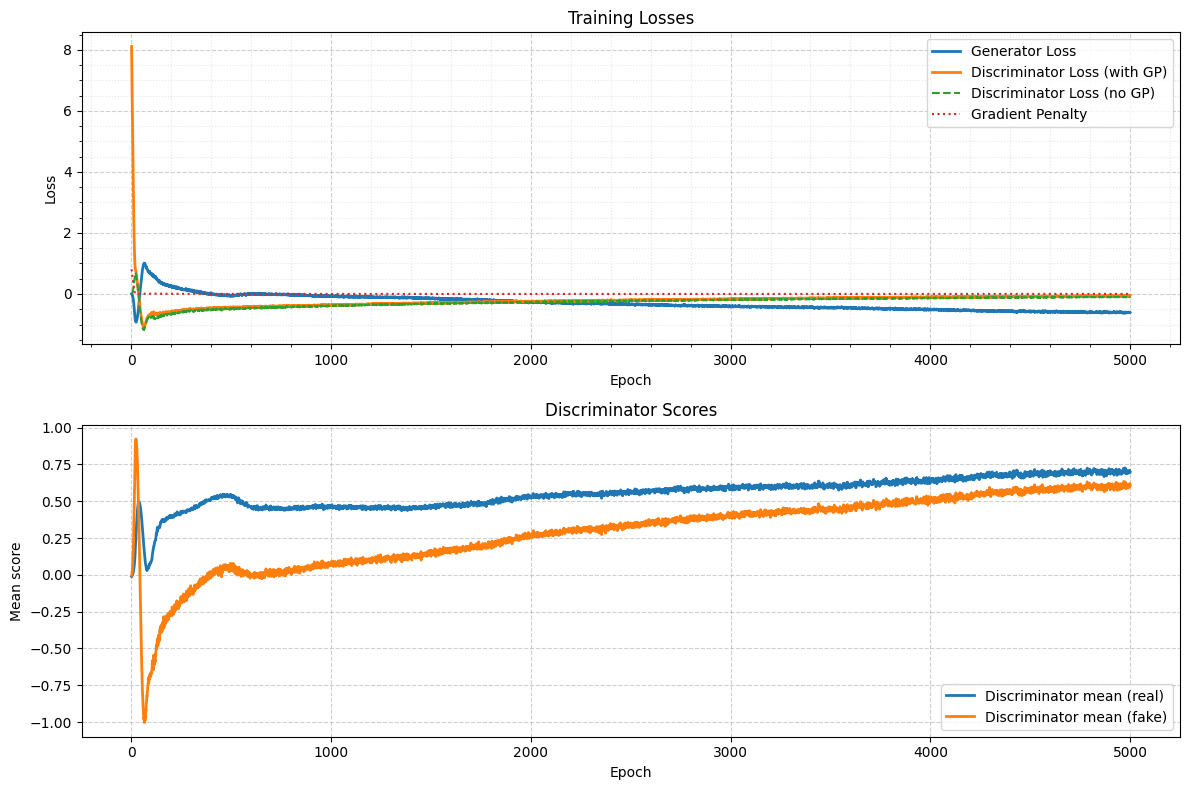

In [33]:
dummy_input_dim = X_train_final.shape[1]


gan = cWGAN_GP(input_dim=dummy_input_dim)
X_t = torch.tensor(X_train_final, dtype=torch.float32)
y_t = torch.tensor(y_train, dtype=torch.long)
cond_onehot = nn.functional.one_hot(y_t, num_classes=gan.num_classes).float()
full_dataset = TensorDataset(X_t, cond_onehot)
train_loader = DataLoader(full_dataset, batch_size=gan.batch_size, shuffle=True)


gan.train(train_loader)
gan.plot_losses()

##### Grid

In [141]:
param_grid = [
    {'kernel': ['rbf'], 'C': [0.1,1,10,100,1000],
     'gamma': [1.05**e for e in range(-100,101,10)]},
    {'kernel': ['linear'], 'C': [0.1,1,10,100,1000]}
]

In [34]:
param_grid = [
    {'kernel': ['linear'], 'C': [100]}
]

##### sampling (original)

In [54]:
def generate_samples(model, n_samples, latent_dim, cond):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, latent_dim)
        return model.decode(z, cond).cpu().numpy()

cv_loocv = LeaveOneOut()

gen_counts = list(range(10, 251, 10))

# dictionary to hold all synthetic samples
all_generated = {}

loocv_scores, test_scores, best_params_all = [], [], []

for r in gen_counts:
    # generate synthetic for class 0 & 1
    cond0 = torch.zeros(r, 2); cond0[:,0] = 1
    cond1 = torch.zeros(r, 2); cond1[:,1] = 1
    synth0 = generate_samples(vae, r, latent_dim_pt, cond0)
    synth1 = generate_samples(vae, r, latent_dim_pt, cond1)

    # store in dict
    all_generated[r] = {
        'synth0': synth0,
        'synth1': synth1
    }

    # augment
    X_aug = np.vstack([X_train_final, synth0, synth1])
    y_aug = np.concatenate([y_train,
                            np.zeros(r),
                            np.ones(r)])

    # LOOCV GridSearch
    grid = GridSearchCV(SVC(), param_grid,
                        scoring="accuracy",
                        cv=cv_loocv, n_jobs=-1)
    grid.fit(X_aug, y_aug)
    loocv_acc = grid.best_score_
    best_p    = grid.best_params_

    # independent test
    clf = SVC(**best_p).fit(X_aug, y_aug)
    test_acc = accuracy_score(y_test,
                              clf.predict(X_test_final))

    loocv_scores.append(loocv_acc)
    test_scores.append(test_acc)
    best_params_all.append(best_p)

    print(f"r={r:4d} | LOOCV Acc: {loocv_acc:.4f} | Test Acc: {test_acc:.4f}")


r=  10 | LOOCV Acc: 0.8909 | Test Acc: 0.8205
r=  20 | LOOCV Acc: 0.8923 | Test Acc: 0.7949
r=  30 | LOOCV Acc: 0.9333 | Test Acc: 0.7949
r=  40 | LOOCV Acc: 0.9118 | Test Acc: 0.7949
r=  50 | LOOCV Acc: 0.8947 | Test Acc: 0.7692
r=  60 | LOOCV Acc: 0.9286 | Test Acc: 0.7949
r=  70 | LOOCV Acc: 0.9261 | Test Acc: 0.7692
r=  80 | LOOCV Acc: 0.9480 | Test Acc: 0.7949
r=  90 | LOOCV Acc: 0.9407 | Test Acc: 0.7949
r= 100 | LOOCV Acc: 0.9414 | Test Acc: 0.7949
r= 110 | LOOCV Acc: 0.9258 | Test Acc: 0.7949
r= 120 | LOOCV Acc: 0.9515 | Test Acc: 0.7949
r= 130 | LOOCV Acc: 0.9514 | Test Acc: 0.7949
r= 140 | LOOCV Acc: 0.9459 | Test Acc: 0.7949
r= 150 | LOOCV Acc: 0.9538 | Test Acc: 0.7949
r= 160 | LOOCV Acc: 0.9463 | Test Acc: 0.7692
r= 170 | LOOCV Acc: 0.9535 | Test Acc: 0.7949
r= 180 | LOOCV Acc: 0.9556 | Test Acc: 0.7949
r= 190 | LOOCV Acc: 0.9553 | Test Acc: 0.7949
r= 200 | LOOCV Acc: 0.9510 | Test Acc: 0.7692
r= 210 | LOOCV Acc: 0.9510 | Test Acc: 0.7692
r= 220 | LOOCV Acc: 0.9566 | Test 

##### sampling (multiple trials)

In [32]:
def generate_samples(model, n_samples, latent_dim, cond):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, latent_dim)
        return model.decode(z, cond).cpu().numpy()

cv_loocv = LeaveOneOut()

gen_counts = list(range(10, 251, 10))

# dictionary to hold all synthetic samples
all_generated = {}

loocv_scores, test_scores, best_params_all = [], [], []

for r in gen_counts:

    best_test_acc = -np.inf
    best_loocv_acc = None
    best_params = None
    best_synth0 = None
    best_synth1 = None


    for trial in range(10):

        cond0 = torch.zeros(r, 2); cond0[:, 0] = 1
        cond1 = torch.zeros(r, 2); cond1[:, 1] = 1


        synth0_candidate = generate_samples(vae, r, latent_dim_pt, cond0)
        synth1_candidate = generate_samples(vae, r, latent_dim_pt, cond1)



        X_aug = np.vstack([X_train_final, synth0_candidate, synth1_candidate])
        y_aug = np.concatenate([y_train,
                                np.zeros(r),
                                np.ones(r)])


        grid = GridSearchCV(SVC(), param_grid,
                            scoring="accuracy",
                            cv=cv_loocv, n_jobs=-1)
        grid.fit(X_aug, y_aug)
        loocv_acc_candidate = grid.best_score_
        params_candidate = grid.best_params_


        clf = SVC(**params_candidate).fit(X_aug, y_aug)
        test_acc_candidate = accuracy_score(
            y_test,
            clf.predict(X_test_final)
        )


        if test_acc_candidate > best_test_acc:
            best_test_acc    = test_acc_candidate
            best_loocv_acc   = loocv_acc_candidate
            best_params      = params_candidate
            best_synth0      = synth0_candidate
            best_synth1      = synth1_candidate


    all_generated[r] = {
        'synth0': best_synth0,
        'synth1': best_synth1
    }

    loocv_scores.append(best_loocv_acc)
    test_scores.append(best_test_acc)
    best_params_all.append(best_params)

    print(f"r={r:4d} | Best LOOCV Acc: {best_loocv_acc:.4f} | Best Test Acc: {best_test_acc:.4f}")

r=  10 | Best LOOCV Acc: 0.9364 | Best Test Acc: 0.7692
r=  20 | Best LOOCV Acc: 0.9231 | Best Test Acc: 0.7692
r=  30 | Best LOOCV Acc: 0.9400 | Best Test Acc: 0.7692
r=  40 | Best LOOCV Acc: 0.9235 | Best Test Acc: 0.7692
r=  50 | Best LOOCV Acc: 0.9474 | Best Test Acc: 0.7692
r=  60 | Best LOOCV Acc: 0.9524 | Best Test Acc: 0.7692
r=  70 | Best LOOCV Acc: 0.9652 | Best Test Acc: 0.7692
r=  80 | Best LOOCV Acc: 0.9640 | Best Test Acc: 0.7692
r=  90 | Best LOOCV Acc: 0.9556 | Best Test Acc: 0.7949
r= 100 | Best LOOCV Acc: 0.9483 | Best Test Acc: 0.7692
r= 110 | Best LOOCV Acc: 0.9419 | Best Test Acc: 0.7949
r= 120 | Best LOOCV Acc: 0.9455 | Best Test Acc: 0.7692
r= 130 | Best LOOCV Acc: 0.9600 | Best Test Acc: 0.7949
r= 140 | Best LOOCV Acc: 0.9595 | Best Test Acc: 0.7949
r= 150 | Best LOOCV Acc: 0.9538 | Best Test Acc: 0.7692
r= 160 | Best LOOCV Acc: 0.9463 | Best Test Acc: 0.7692
r= 170 | Best LOOCV Acc: 0.9628 | Best Test Acc: 0.7692
r= 180 | Best LOOCV Acc: 0.9578 | Best Test Acc:

##### sampling w/ SVDD

In [79]:
epsilon = 1e-3 * 3  

cv_loocv = LeaveOneOut()
gen_counts = list(range(10, 251, 10))

# Train One-Class SVM (SVDD) on final real training features (unchanged)
svdd0 = OneClassSVM(kernel='rbf', gamma=40, nu=0.01).fit(X_train_final[y_train == 0])
svdd1 = OneClassSVM(kernel='rbf', gamma=40, nu=0.01).fit(X_train_final[y_train == 1])


def generate_samples(model_inst, n_samples, cond):
    model_inst.generator.eval()
    device = model_inst.device
    with torch.no_grad():
        z = torch.randn(n_samples, model_inst.latent_dim, device=device)
        if isinstance(cond, torch.Tensor):
            cond_t = cond.to(device)
            if cond_t.size(0) != n_samples:
                cond_t = cond_t[:n_samples]
        else:
            cond_t = torch.tensor(cond, dtype=torch.float32, device=device)
            if cond_t.size(0) != n_samples:
                cond_t = cond_t[:n_samples]
        gen = model_inst.decode(z, cond_t)
    return gen.cpu().numpy()


def generate_with_svdd(cond, svdd, target_n):
    accepted = []
    total_generated = 0
    while len(accepted) < target_n:
        to_gen = target_n - len(accepted)
        cond_batch = cond[:to_gen]
        candidates = generate_samples(gan, to_gen, cond_batch)
        total_generated += len(candidates)
        dec = svdd.decision_function(candidates)
        mask = dec >= -epsilon
        accepted.extend(candidates[mask])
    accepted = np.array(accepted[:target_n])
    return accepted, total_generated


all_generated = {}
loocv_scores, test_scores, best_params_all = [], [], []
filter_stats = {}

for r in gen_counts:
    best_test_acc  = -np.inf
    best_loocv_acc = None
    best_params    = None
    best_synth0    = None
    best_synth1    = None

    filter_stats[r] = []

    for trial in range(1):
        cond0 = torch.zeros(r, gan.num_classes); cond0[:, 0] = 1
        cond1 = torch.zeros(r, gan.num_classes); cond1[:, 1] = 1

        synth0_candidate, gen0 = generate_with_svdd(cond0, svdd0, r)
        synth1_candidate, gen1 = generate_with_svdd(cond1, svdd1, r)

        total_required = 2 * r
        total_generated = gen0 + gen1
        filtered_percent = (1 - total_required / total_generated) * 100
        filter_stats[r].append(filtered_percent)

        X_aug = np.vstack([X_train_final, synth0_candidate, synth1_candidate])
        y_aug = np.concatenate([y_train, np.zeros(r), np.ones(r)])

        # LOOCV GridSearch
        grid = GridSearchCV(SVC(), param_grid, scoring="accuracy", cv=cv_loocv, n_jobs=-1)
        grid.fit(X_aug, y_aug)
        loocv_acc_candidate = grid.best_score_
        params_candidate    = grid.best_params_

        clf = SVC(**params_candidate).fit(X_aug, y_aug)
        test_acc_candidate = accuracy_score(y_test, clf.predict(X_test_final))

        if test_acc_candidate > best_test_acc:
            best_test_acc   = test_acc_candidate
            best_loocv_acc  = loocv_acc_candidate
            best_params     = params_candidate
            best_synth0     = synth0_candidate
            best_synth1     = synth1_candidate

    avg_filtered_r = np.mean(filter_stats[r])

    all_generated[r] = {'synth0': best_synth0, 'synth1': best_synth1}
    loocv_scores.append(best_loocv_acc)
    test_scores.append(best_test_acc)
    best_params_all.append(best_params)

    print(f"r={r:4d} | Best LOOCV Acc: {best_loocv_acc:.4f} | "
          f"Best Test Acc: {best_test_acc:.4f} | "
          f"Avg Filtered: {avg_filtered_r:.2f}%")

all_filtered_values = [p for vals in filter_stats.values() for p in vals]
overall_avg_filtered = np.mean(all_filtered_values)
print(f"\nOverall Avg Filtered Across All gen_counts: {overall_avg_filtered:.2f}%")

r=  10 | Best LOOCV Acc: 0.9273 | Best Test Acc: 0.7692 | Avg Filtered: 99.41%
r=  20 | Best LOOCV Acc: 0.9538 | Best Test Acc: 0.7692 | Avg Filtered: 99.58%
r=  30 | Best LOOCV Acc: 0.9400 | Best Test Acc: 0.7692 | Avg Filtered: 99.46%
r=  40 | Best LOOCV Acc: 0.9353 | Best Test Acc: 0.7949 | Avg Filtered: 99.47%
r=  50 | Best LOOCV Acc: 0.9632 | Best Test Acc: 0.7949 | Avg Filtered: 99.37%
r=  60 | Best LOOCV Acc: 0.9619 | Best Test Acc: 0.7692 | Avg Filtered: 99.44%
r=  70 | Best LOOCV Acc: 0.9609 | Best Test Acc: 0.7949 | Avg Filtered: 99.50%
r=  80 | Best LOOCV Acc: 0.9480 | Best Test Acc: 0.7949 | Avg Filtered: 99.40%
r=  90 | Best LOOCV Acc: 0.9778 | Best Test Acc: 0.7692 | Avg Filtered: 99.39%
r= 100 | Best LOOCV Acc: 0.9690 | Best Test Acc: 0.7949 | Avg Filtered: 99.43%
r= 110 | Best LOOCV Acc: 0.9581 | Best Test Acc: 0.7949 | Avg Filtered: 99.38%
r= 120 | Best LOOCV Acc: 0.9788 | Best Test Acc: 0.7949 | Avg Filtered: 99.45%
r= 130 | Best LOOCV Acc: 0.9829 | Best Test Acc: 0.7

##### SVDD radius calculation

In [23]:
from sklearn.metrics.pairwise import rbf_kernel

svdd0 = OneClassSVM(kernel='rbf', gamma=27, nu=0.01).fit(
    X_train_final[y_train == 0]
)
svdd1 = OneClassSVM(kernel='rbf', gamma=27, nu=0.01).fit(
    X_train_final[y_train == 1]
)


def compute_svdd_radius(svdd):

    SV = svdd.support_vectors_
    alphas = svdd.dual_coef_[0]
    gamma = svdd.gamma

    K = rbf_kernel(SV, SV, gamma=gamma)

    K_diag = np.diag(K)
    term2 = 2 * K.dot(alphas)
    term3 = alphas.dot(K.dot(alphas))
    R2 = np.mean(K_diag - term2 + term3)

    return np.sqrt(R2)

def epsilon_percent_of_radius(svdd, epsilon):

    R = compute_svdd_radius(svdd)
    percent = epsilon / R * 100
    print(f"SVDD radious R = {R:.6f}")
    print(f"ε = {epsilon:.6f} equals {percent:.2f}% of SVDD radius R")
    return percent


epsilon = 1e-3 * 30


percent0 = epsilon_percent_of_radius(svdd0, epsilon)
percent1 = epsilon_percent_of_radius(svdd1, epsilon)

SVDD radious R = 0.992218
ε = 0.030000 equals 3.02% of SVDD radius R
SVDD radious R = 0.991893
ε = 0.030000 equals 3.02% of SVDD radius R


##### save result

In [56]:
with open("../result_LSVM/BD_MDD/all_feature/BVAE/ep=10%/all_generated_samples.pkl", "wb") as f:
    pickle.dump(all_generated, f)

# save LOOCV/test history
with open("../result_LSVM/BD_MDD/all_feature/BVAE/ep=10%/svm_loocv_test_history.pkl", "wb") as f:
    pickle.dump({
        "gen_counts": gen_counts,
        "loocv_scores": loocv_scores,
        "test_scores": test_scores,
        "best_params": best_params_all
    }, f)

##### plot accuracy curve

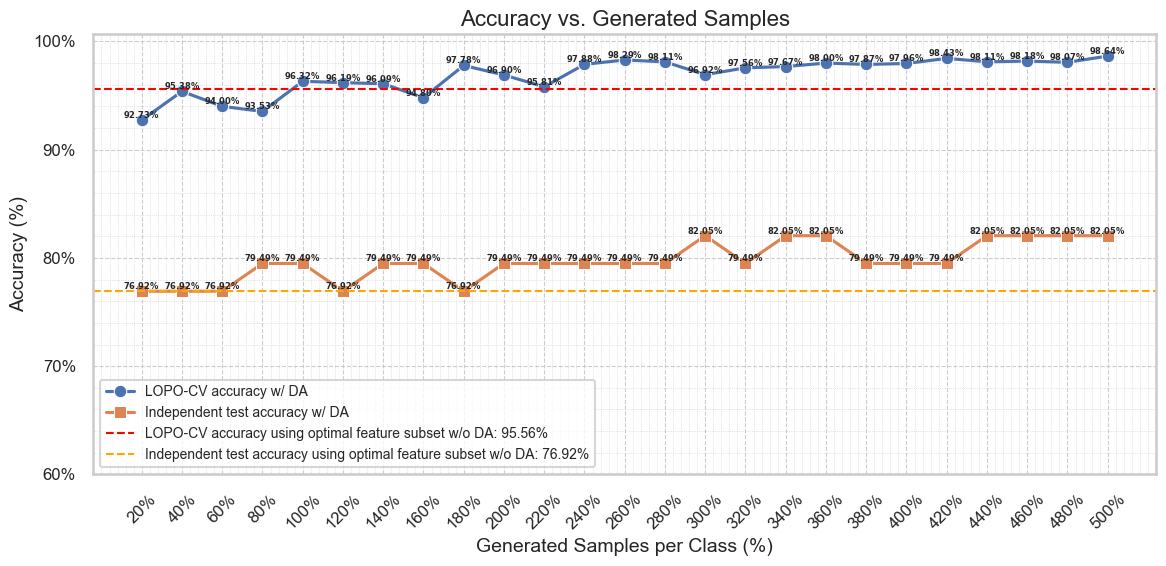

In [ ]:
loocv_pct = [s * 100 for s in loocv_scores]
test_pct  = [s * 100 for s in test_scores]

# y low limit
min_val = min(loocv_pct + test_pct)
lower = int(np.floor((min_val - 10) / 10)) * 10
lower = max(lower, 0)

# y top limit
max_val = max(loocv_pct + test_pct)
upper = max_val + 2
upper = min(upper, 102)  


sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(12, 6))



sns.lineplot(
    x=gen_counts, y=loocv_pct, marker="o",
    label="LOPO-CV accuracy w/ DA", ax=ax, clip_on=False,
)
sns.lineplot(
    x=gen_counts, y=test_pct, marker="s",
    label="Independent test accuracy w/ DA", ax=ax, clip_on=False
)



for x, y in zip(gen_counts, loocv_pct):
    ax.text(
        x, y, f"$\\mathbf{{{y:.2f}\\%}}$", va='bottom', ha='center',
        fontsize=6, clip_on=False, 
    )

for x, y in zip(gen_counts, test_pct):
    ax.text(
        x, y, f"$\\mathbf{{{y:.2f}\\%}}$", va='bottom', ha='center',
        fontsize=6, clip_on=False
    )



# baseline
baseline = 95.56
ax.axhline(
    baseline, linestyle='--', label=f'LOPO-CV accuracy using optimal feature subset w/o DA: {baseline}%',
    clip_on=False, color='red', linewidth=1.5
)

baseline_2 = 76.92
ax.axhline(
    baseline_2, linestyle='--', label=f'Independent test accuracy using optimal feature subset w/o DA: {baseline_2}%',
    clip_on=False, color='orange', linewidth=1.5
)

# X axis
ax.set_xticks(gen_counts)
ax.set_xticklabels([f"{x*2}%" for x in gen_counts], rotation=45)

# Y axis
ax.set_ylim(lower, upper)
yticks = list(range(lower, 101, 10))
ax.set_yticks(yticks)
ax.set_yticklabels([f"{y}%" for y in yticks])

ax.tick_params(axis='both', labelsize=12)   
ax.set_xlabel("Generated Samples per Class (%)", fontsize=14)
ax.set_ylabel("Accuracy (%)", fontsize=14)
ax.set_title("Accuracy vs. Generated Samples", fontsize=16)
ax.minorticks_on()
ax.grid(which="major", linestyle="--", linewidth=0.8)
ax.grid(which="minor", linestyle=":", linewidth=0.5)
ax.legend(fontsize=10)

plt.tight_layout()
# plt.savefig("../result_GAN/BD_MDD/optimal_feature/ep=0.5%/accuracy_vs_generated_samples.png", dpi=3000)
plt.show()

In [43]:
average_loocv = np.mean(loocv_scores) * 100
average_test  = np.mean(test_scores) * 100
print(f"Average LOOCV accuracy: {average_loocv:.2f}%")
print(f"Average independent test accuracy: {average_test:.2f}%")

Average LOOCV accuracy: 93.83%
Average independent test accuracy: 79.18%


##### average SWD

Gaussian Noise SWD (averaged over classes): 0.7877
Real Data Split SWD (averaged over classes): 0.0340
Average Generated vs Real SWD: 0.0462
Average Generated vs Shuffled Real SWD: 0.0550


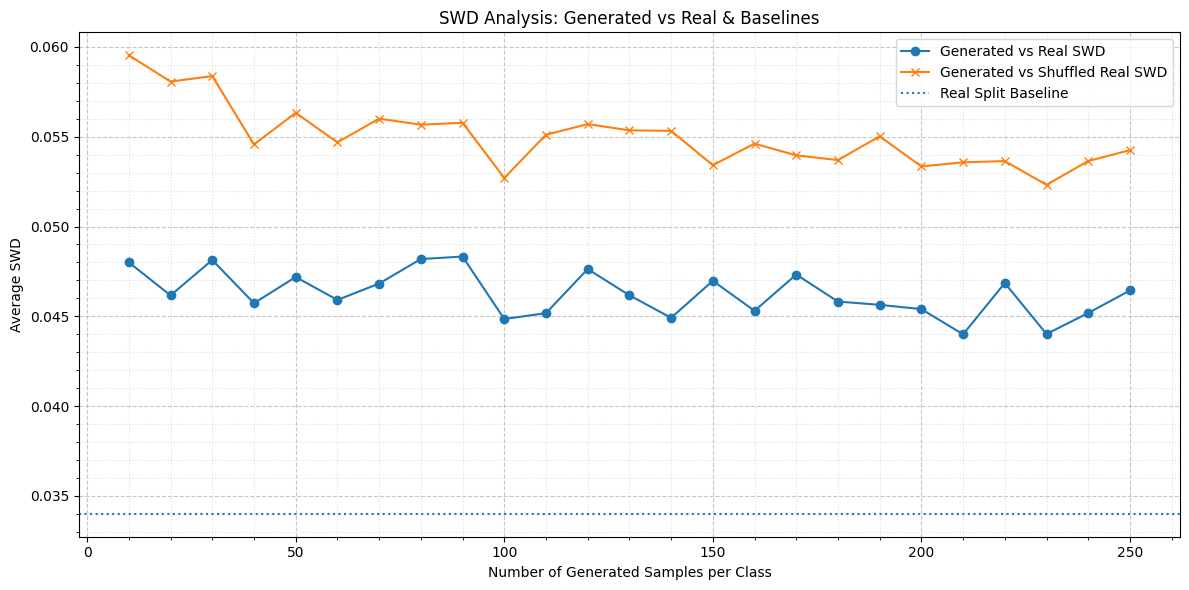

In [58]:
# Reset Seaborn to default settings
sns.reset_defaults()

# Sliced Wasserstein Distance function
def sliced_wasserstein_distance(X, Y, num_projections=100):
    d = X.shape[1]
    swd = 0.0
    for _ in range(num_projections):
        direction = np.random.randn(d)
        direction /= np.linalg.norm(direction)
        projX = X @ direction
        projY = Y @ direction
        m = max(len(projX), len(projY))
        qs = np.linspace(0, 1, m)
        qx = np.quantile(projX, qs)
        qy = np.quantile(projY, qs)
        swd += np.mean(np.abs(qx - qy))
    return swd / num_projections

# Original data by class
orig0 = X_train_final[y_train == 0]
orig1 = X_train_final[y_train == 1]

# 1. Baseline: Gaussian noise vs. real samples
noise0 = np.random.randn(*orig0.shape)
noise1 = np.random.randn(*orig1.shape)
swd_noise0 = sliced_wasserstein_distance(noise0, orig0)
swd_noise1 = sliced_wasserstein_distance(noise1, orig1)
gaussian_swd = (swd_noise0 + swd_noise1) / 2
print(f'Gaussian Noise SWD (averaged over classes): {gaussian_swd:.4f}')

# 2. Baseline: Split real data into halves and compute SWD
def compute_split_swd(data):
    n = len(data)
    idxs = np.random.permutation(n)
    half = n // 2
    part1 = data[idxs[:half]]
    part2 = data[idxs[half:2*half]]
    return sliced_wasserstein_distance(part1, part2)

swd_split0 = compute_split_swd(orig0)
swd_split1 = compute_split_swd(orig1)
split_swd = (swd_split0 + swd_split1) / 2
print(f'Real Data Split SWD (averaged over classes): {split_swd:.4f}')

# 3. Prepare shuffled real data across all classes
shuffled_all = shuffle(X_train_final, random_state=43)
shuffled0 = shuffled_all[:len(orig0)]
shuffled1 = shuffled_all[len(orig0):len(orig0)+len(orig1)]

# 4. SWD for generated vs real & generated vs shuffled real
swd_means = []
swd_shuffled = []

for r in gen_counts:
    synth0 = all_generated[r]['synth0']
    synth1 = all_generated[r]['synth1']
    
    # Generated vs Real
    swd0 = sliced_wasserstein_distance(synth0, orig0)
    swd1 = sliced_wasserstein_distance(synth1, orig1)
    swd_means.append((swd0 + swd1) / 2)
    
    # Generated vs Shuffled Real (across classes)
    swd0_shuf = sliced_wasserstein_distance(synth0, shuffled0)
    swd1_shuf = sliced_wasserstein_distance(synth1, shuffled1)
    swd_shuffled.append((swd0_shuf + swd1_shuf) / 2)

# Print overall average SWD for generated data
overall_avg_swd = np.mean(swd_means)
print(f'Average Generated vs Real SWD: {overall_avg_swd:.4f}')
# Print overall average SWD for generated vs shuffled real data
overall_avg_swd_shuffled = np.mean(swd_shuffled)
print(f'Average Generated vs Shuffled Real SWD: {overall_avg_swd_shuffled:.4f}')

# Plot SWD curves (excluding Gaussian noise baseline if desired)
plt.figure(figsize=(12, 6))
plt.plot(gen_counts, swd_means, marker='o', label='Generated vs Real SWD')
plt.plot(gen_counts, swd_shuffled, marker='x', label='Generated vs Shuffled Real SWD')
plt.axhline(split_swd, linestyle=':', label='Real Split Baseline')
plt.xlabel('Number of Generated Samples per Class')
plt.ylabel('Average SWD')
plt.title('SWD Analysis: Generated vs Real & Baselines')
plt.legend()
plt.grid(which='major', linestyle='--', alpha=0.7)
plt.minorticks_on()
plt.grid(which='minor', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

Real Classes SWD: 0.0617
Gaussian Noise SWD (averaged over classes): 0.7752
Real Data Split SWD (averaged over classes): 0.0277
Average Generated vs Real SWD: 0.0516
Average Generated vs Shuffled Real SWD: 0.0530


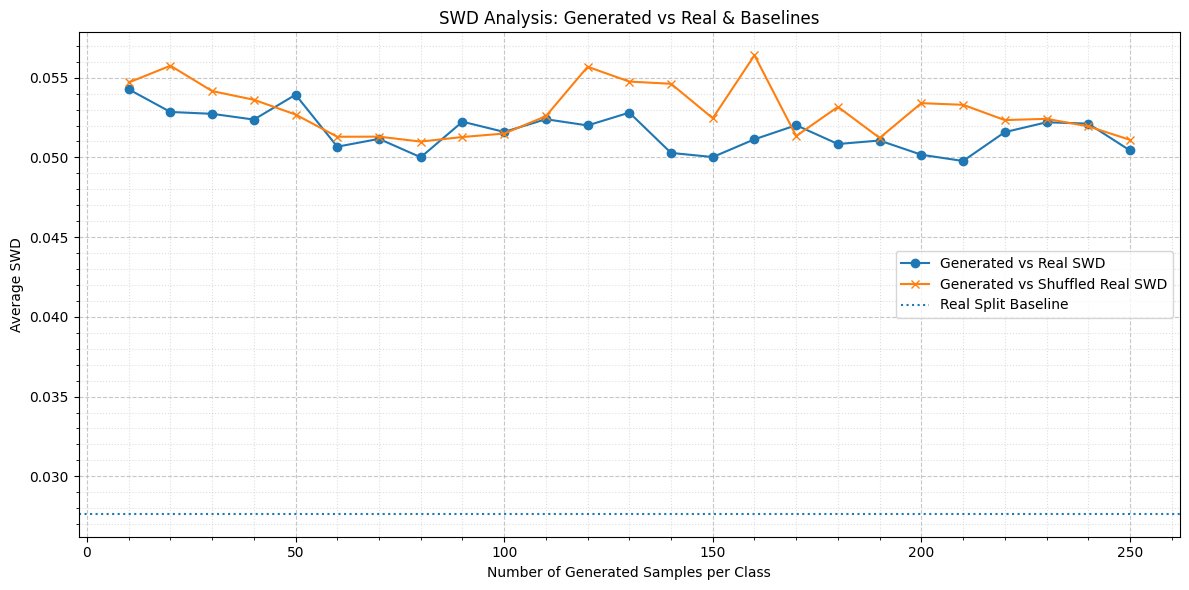

In [63]:
# Reset Seaborn to default settings
sns.reset_defaults()

# Sliced Wasserstein Distance function
def sliced_wasserstein_distance(X, Y, num_projections=100):
    d = X.shape[1]
    swd = 0.0
    for _ in range(num_projections):
        direction = np.random.randn(d)
        direction /= np.linalg.norm(direction)
        projX = X @ direction
        projY = Y @ direction
        m = max(len(projX), len(projY))
        qs = np.linspace(0, 1, m)
        qx = np.quantile(projX, qs)
        qy = np.quantile(projY, qs)
        swd += np.mean(np.abs(qx - qy))
    return swd / num_projections

# Original data by class
orig0 = X_train_final[y_train == 0]
orig1 = X_train_final[y_train == 1]

# Compute SWD between the two real classes
swd_between_real = sliced_wasserstein_distance(orig0, orig1)
print(f'Real Classes SWD: {swd_between_real:.4f}')

# 1. Baseline: Gaussian noise vs. real samples
noise0 = np.random.randn(*orig0.shape)
noise1 = np.random.randn(*orig1.shape)
swd_noise0 = sliced_wasserstein_distance(noise0, orig0)
swd_noise1 = sliced_wasserstein_distance(noise1, orig1)
gaussian_swd = (swd_noise0 + swd_noise1) / 2
print(f'Gaussian Noise SWD (averaged over classes): {gaussian_swd:.4f}')

# 2. Baseline: Split real data into halves and compute SWD
def compute_split_swd(data):
    n = len(data)
    idxs = np.random.permutation(n)
    half = n // 2
    part1 = data[idxs[:half]]
    part2 = data[idxs[half:2*half]]
    return sliced_wasserstein_distance(part1, part2)

swd_split0 = compute_split_swd(orig0)
swd_split1 = compute_split_swd(orig1)
split_swd = (swd_split0 + swd_split1) / 2
print(f'Real Data Split SWD (averaged over classes): {split_swd:.4f}')

# 3. Prepare shuffled real data across all classes
shuffled_all = shuffle(X_train_final, random_state=43)
shuffled0 = shuffled_all[:len(orig0)]
shuffled1 = shuffled_all[len(orig0):len(orig0)+len(orig1)]

# 4. SWD for generated vs real & generated vs shuffled real
swd_means = []
swd_shuffled = []

for r in gen_counts:
    synth0 = all_generated[r]['synth0']
    synth1 = all_generated[r]['synth1']
    
    # Generated vs Real
    swd0 = sliced_wasserstein_distance(synth0, orig0)
    swd1 = sliced_wasserstein_distance(synth1, orig1)
    swd_means.append((swd0 + swd1) / 2)
    
    # Generated vs Shuffled Real (across classes)
    swd0_shuf = sliced_wasserstein_distance(synth0, shuffled0)
    swd1_shuf = sliced_wasserstein_distance(synth1, shuffled1)
    swd_shuffled.append((swd0_shuf + swd1_shuf) / 2)

# Print overall average SWD for generated data
overall_avg_swd = np.mean(swd_means)
print(f'Average Generated vs Real SWD: {overall_avg_swd:.4f}')
# Print overall average SWD for generated vs shuffled real data
overall_avg_swd_shuffled = np.mean(swd_shuffled)
print(f'Average Generated vs Shuffled Real SWD: {overall_avg_swd_shuffled:.4f}')

# Plot SWD curves (excluding Gaussian noise baseline if desired)
plt.figure(figsize=(12, 6))
plt.plot(gen_counts, swd_means, marker='o', label='Generated vs Real SWD')
plt.plot(gen_counts, swd_shuffled, marker='x', label='Generated vs Shuffled Real SWD')
plt.axhline(split_swd, linestyle=':', label='Real Split Baseline')
plt.xlabel('Number of Generated Samples per Class')
plt.ylabel('Average SWD')
plt.title('SWD Analysis: Generated vs Real & Baselines')
plt.legend()
plt.grid(which='major', linestyle='--', alpha=0.7)
plt.minorticks_on()
plt.grid(which='minor', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()


##### load result

In [40]:
with open('../result_LSVM/BD_MDD/all_feature/BVAE/ep=10%/all_generated_samples.pkl', 'rb') as f:
    all_generated = pickle.load(f)


with open('../result_LSVM/BD_MDD/all_feature/BVAE/ep=10%/svm_loocv_test_history.pkl', 'rb') as f:
    history = pickle.load(f)

In [41]:
gen_counts = history['gen_counts']
loocv_scores = history['loocv_scores']
test_scores = history['test_scores']
best_params_all = history['best_params']

In [17]:
vae = cVAE(input_dim=dummy_input_dim, latent_dim=latent_dim_pt, num_classes=num_classes)
checkpoint = torch.load(
    "../result_LSVM/BD_MDD/all_feature/BVAE/original_vae/vae_model.pt",
    map_location=torch.device('cpu')
)
vae.load_state_dict(checkpoint)
vae.eval()

C:\Users\NESS-Kuan\AppData\Local\Temp\ipykernel_15664\1096739815.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


cVAE(
  (conv1d_enc): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (fc_enc): Sequential(
    (0): Linear(in_features=6402, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (fc_mu): Linear(in_features=32, out_features=15, bias=True)
  (fc_logvar): Linear(in_features=32, out_feature

##### plot t-SNE & confusion matrix

In [76]:
sns.reset_defaults()
cv_loocv = LeaveOneOut()


def plot_combined_confusion(r, params, filename=None):

    synth0 = all_generated[r]['synth0']
    synth1 = all_generated[r]['synth1']

    # augment train set
    X_aug = np.vstack([X_train_final, synth0, synth1])
    y_aug = np.concatenate([y_train, np.zeros(r), np.ones(r)])


    y_pred_loocv = cross_val_predict(
        SVC(**params), X_aug, y_aug, cv=cv_loocv, n_jobs=-1
    )
    cm_loocv = confusion_matrix(y_aug, y_pred_loocv)

    clf = SVC(**params)
    clf.fit(X_aug, y_aug)
    y_pred_test = clf.predict(X_test_final)
    cm_test = confusion_matrix(y_test, y_pred_test)


    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ---- LOPO-CV ----
    disp1 = ConfusionMatrixDisplay(
        cm_loocv,
        display_labels=["BD-II", "MDD"]
    )
    disp1.plot(
        ax=axes[0],
        cmap=plt.cm.Blues,
        colorbar=False,
        text_kw={'fontsize': 14}       # enlarge cell text
    )
    axes[0].set_title(
        f"LOPO-CV confusion matrix\n(generated data per class={r*2}%)",
        fontsize=16,                   # enlarge title
        pad=12
    )
    axes[0].tick_params(axis='both', labelsize=14)  # enlarge tick labels
    axes[0].set_xlabel(axes[0].get_xlabel(), fontsize=14)
    axes[0].set_ylabel(axes[0].get_ylabel(), fontsize=14)

    # ---- Independent Test ----
    disp2 = ConfusionMatrixDisplay(
        cm_test,
        display_labels=["BD-II", "MDD"]
    )
    disp2.plot(
        ax=axes[1],
        cmap=plt.cm.Blues,
        colorbar=False,
        text_kw={'fontsize': 14}
    )
    axes[1].set_title(
        f"Independent test confusion matrix\n(generated data per class={r*2}%)",
        fontsize=16,
        pad=12
    )
    axes[1].tick_params(axis='both', labelsize=14)
    axes[1].set_xlabel(axes[1].get_xlabel(), fontsize=14)
    axes[1].set_ylabel(axes[1].get_ylabel(), fontsize=14)

    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename, dpi=300)
    plt.show()




def plot_tsne(r, params, filename=None):
    synth0 = all_generated[r]['synth0']
    synth1 = all_generated[r]['synth1']

    
    X_vis = np.vstack([X_train_final, synth0, synth1, X_test_final])
    y_vis = np.concatenate([y_train, np.zeros(r), np.ones(r), y_test])
    types = (
        ['train'] * len(X_train_final) +
        ['gen']  * (2 * r) +
        ['test'] * len(X_test_final)
    )


    emb = TSNE(n_components=2, random_state=43)
    emb_results = emb.fit_transform(X_vis)

 
    color_map = {
        (0, 'train'): 'tab:blue',   (0, 'gen'): 'skyblue',   (0, 'test'): 'navy',
        (1, 'train'): 'tab:orange', (1, 'gen'): 'lightsalmon', (1, 'test'): 'darkorange'
    }
    marker_map = {'train': 'o', 'gen': '^', 'test': 'x'}


    fig, ax = plt.subplots(figsize=(8, 6))
    for cls in [0, 1]:
        for t in ['train', 'gen', 'test']:
            idx = np.where((y_vis == cls) & (np.array(types) == t))
            ax.scatter(
                emb_results[idx, 0], emb_results[idx, 1],
                label=f"{['BDII','MDD'][cls]}-{t}",
                marker=marker_map[t],
                color=color_map[(cls, t)],
                alpha=0.7
            )

    ax.legend(fontsize=8, markerscale=0.8)
    ax.set_title(f"t-SNE (generated data per class={r*2}%)")
    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename, dpi=300)
    plt.show()

In [77]:
best_loocv_r = gen_counts[np.argmax(loocv_scores)]
best_loocv_p = best_params_all[np.argmax(loocv_scores)]

best_test_r  = gen_counts[np.argmax(test_scores)]
best_test_p  = best_params_all[np.argmax(test_scores)]

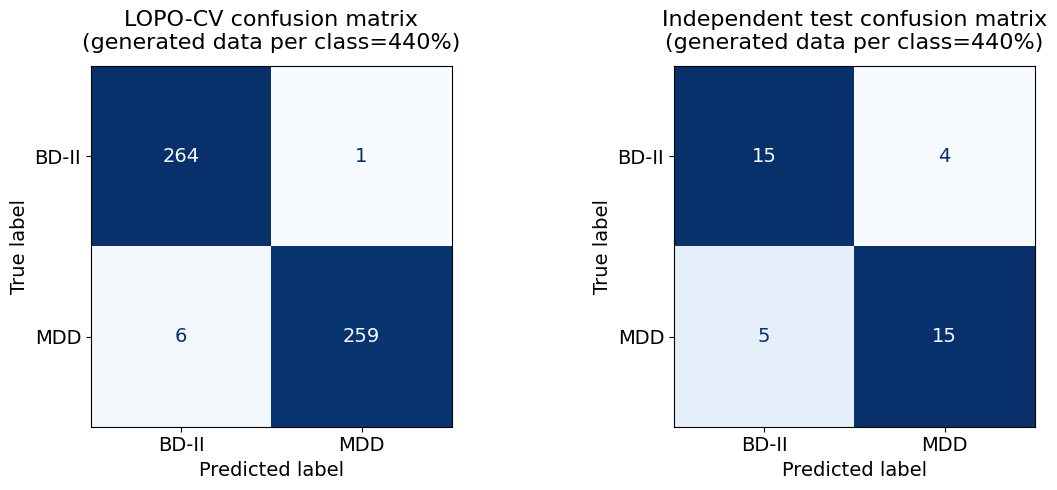

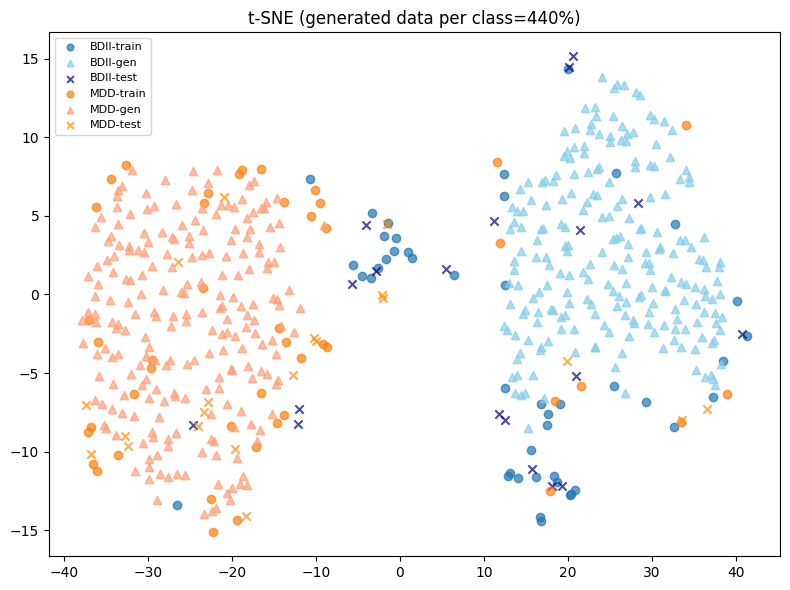

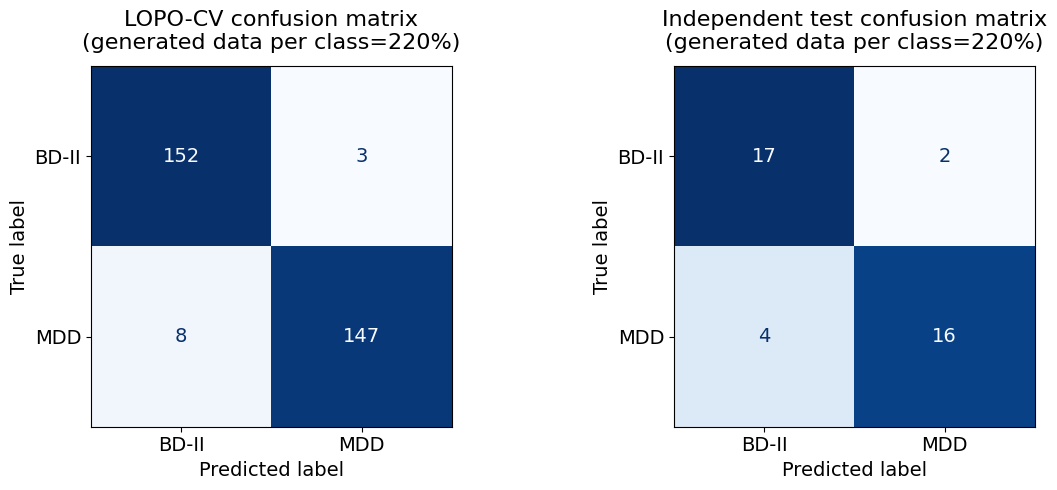

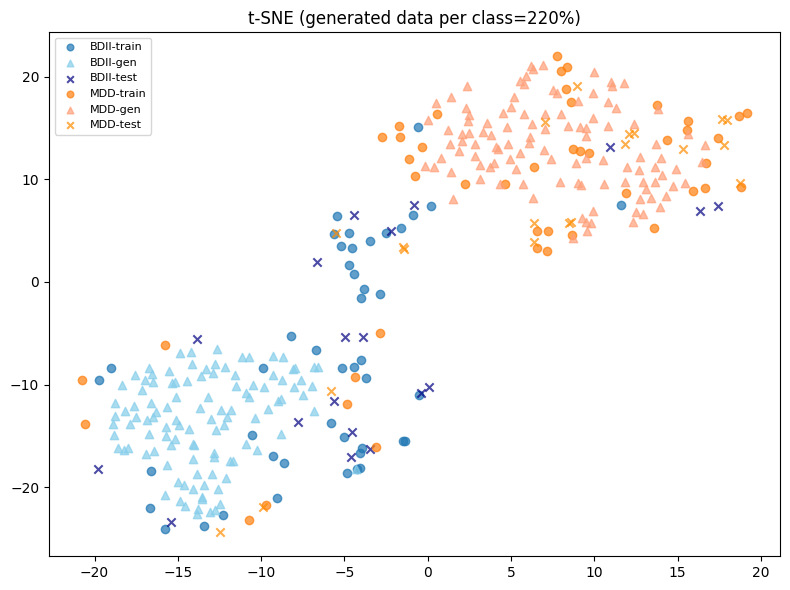

In [78]:
plot_combined_confusion(
    best_loocv_r, best_loocv_p,
)
plot_tsne(
    best_loocv_r, best_loocv_p,
)


plot_combined_confusion(
    best_test_r, best_test_p,
)
plot_tsne(
    best_test_r, best_test_p,
)

##### save t-SNE & confusion matrix

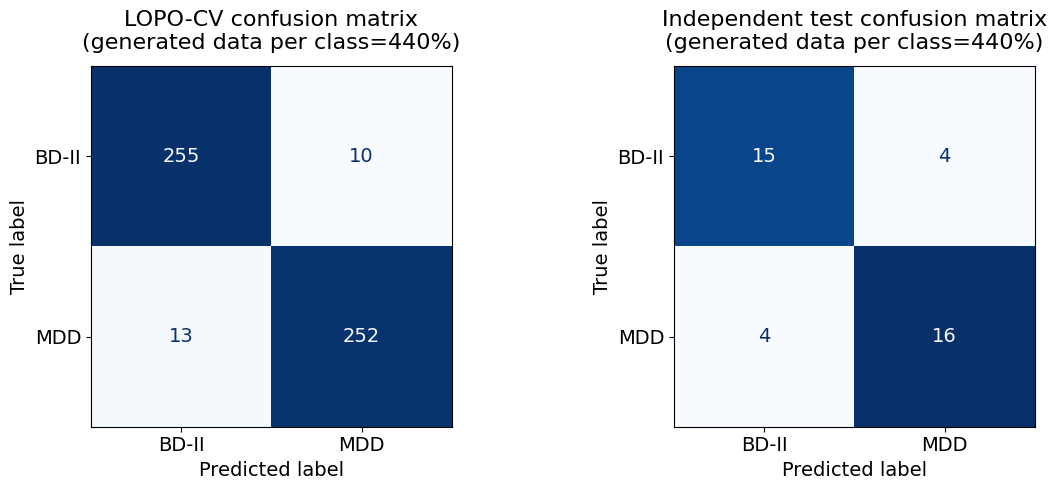

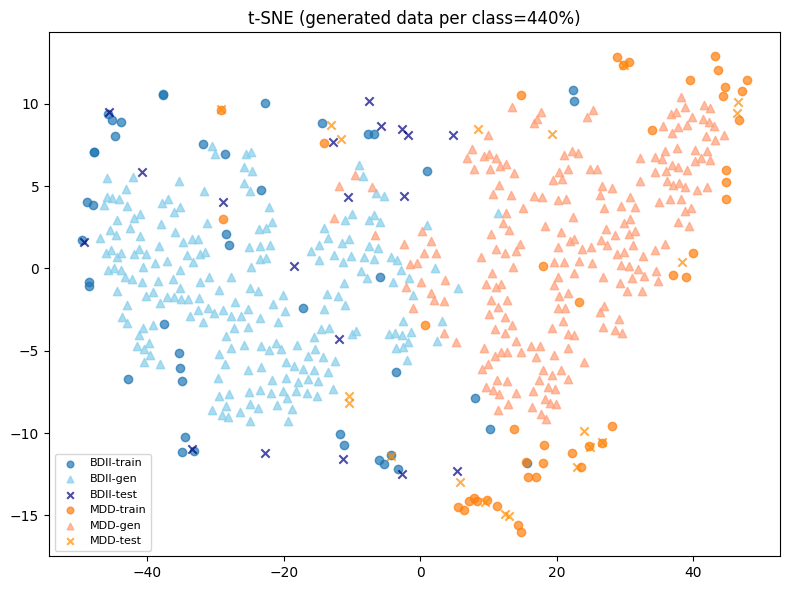

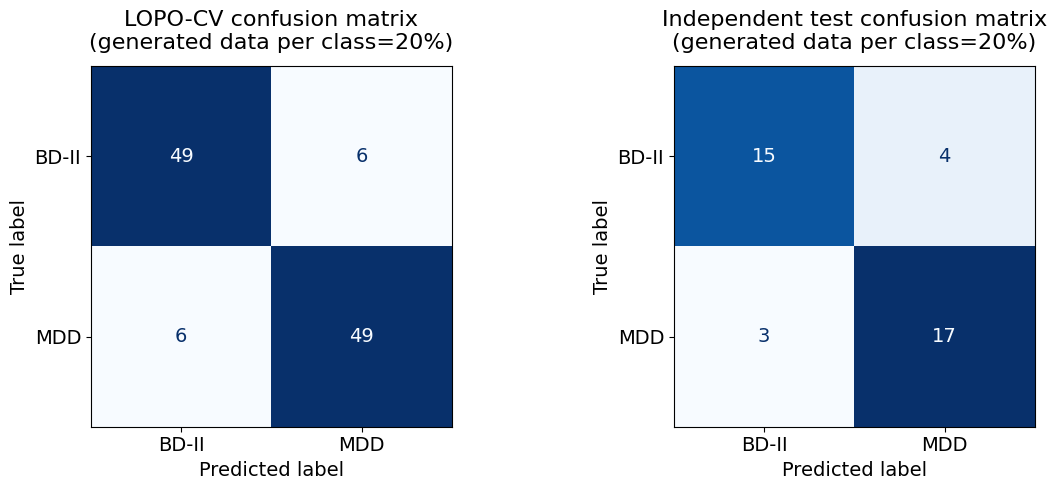

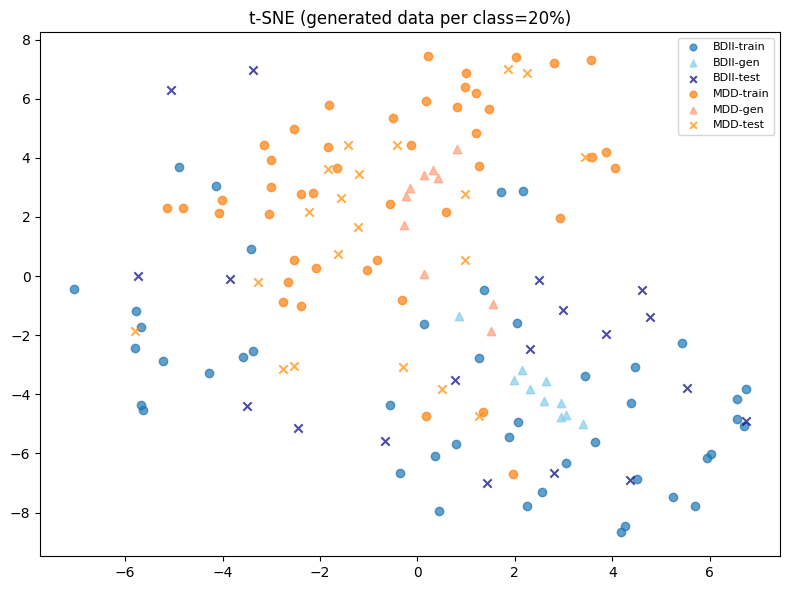

In [62]:
plot_combined_confusion(
    best_loocv_r, best_loocv_p,
    f"../result_LSVM/BD_MDD/all_feature/BVAE/ep=10%/cm_combined_loocv_r{best_loocv_r}.png"
)
plot_tsne(
    best_loocv_r, best_loocv_p,
    f"../result_LSVM/BD_MDD/all_feature/BVAE/ep=10%/tsne_loocv_r{best_loocv_r}.png"
)


plot_combined_confusion(
    best_test_r, best_test_p,
    f"../result_LSVM/BD_MDD/all_feature/BVAE/ep=10%/cm_combined_test_r{best_test_r}.png"
)
plot_tsne(
    best_test_r, best_test_p,
    f"../result_LSVM/BD_MDD/all_feature/BVAE/ep=10%/tsne_test_r{best_test_r}.png")

##### save model

In [46]:
model = gan.state_dict()
with open("../result_GAN/BD_MDD/optimal_feature/ep=0.5%/gan_model.pt", "wb") as f:
    torch.save(model, f)

##### Ind. test distribution

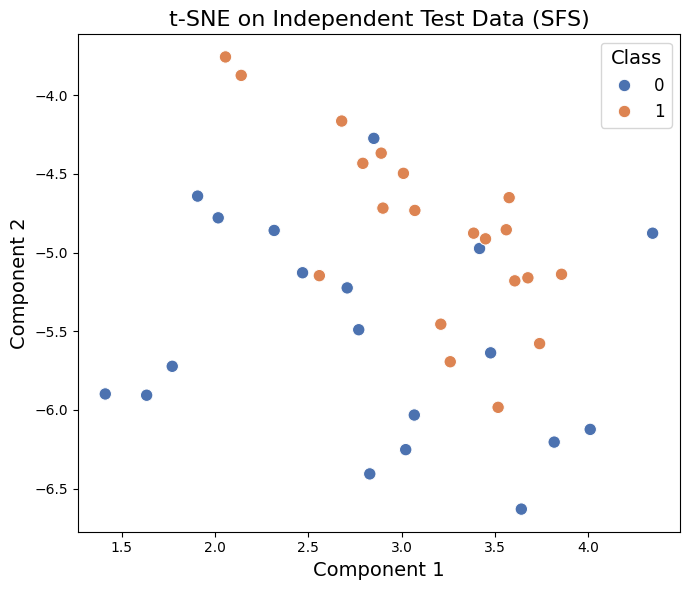

In [27]:
tsne_test = TSNE(n_components=2, random_state=42)
X_tsne_test = tsne_test.fit_transform(X_test_final)
plt.figure(figsize=(7,6))
sns.scatterplot(x=X_tsne_test[:,0], y=X_tsne_test[:,1], 
                hue=y_test.astype(int), palette="deep", s=80)
plt.title("t-SNE on Independent Test Data (SFS)", fontsize=16)
plt.xlabel("Component 1", fontsize=14)
plt.ylabel("Component 2", fontsize=14)
plt.legend(title="Class", fontsize=12, title_fontsize=14)
plt.tight_layout()
plt.savefig("tsne_independent_test.png", dpi=300)
plt.show()